In [1]:
import numpy as np
import sympy as sp 
import scipy as Sp
import numpy.linalg as linal 
import matplotlib.pyplot as plt

In [2]:
n = sp.symbols("n")
w = sp.symbols("w")
W = sp.Piecewise((sp.cos(w+sp.pi/2), (w>=-sp.pi)&(w< -sp.pi/2)), (1, (w>=-sp.pi/2)&(w<sp.pi/2)), (sp.cos(w-sp.pi/2), (w>=sp.pi/2)&(w<=sp.pi)))

In [3]:
cexp = sp.exp(1.0j*w*n)

coeffs = sp.integrate(W*cexp/(2*sp.pi), (w, -sp.pi, sp.pi))

In [4]:
coeffs_num = sp.lambdify(n, coeffs)

In [5]:
coeffs_num(2)

array(-0.1061033+0.j)

In [6]:
vals = sp.integrate(W*W/(2*sp.pi), (w, -sp.pi, sp.pi))

In [7]:
0.95*0.75

0.7124999999999999

In [8]:
sum = 0

for i in range(2) : 
    sum = sum + 2*(coeffs_num(i)**2)

print(sum-coeffs_num(0)**2)

(0.7202916616472974+0j)


<lambdifygenerated-1>:2: RuntimeWarning: divide by zero encountered in cdouble_scalars
  return select([logical_or.reduce((equal(n, -1.0),equal(n, 1.0))),logical_and.reduce((greater(n, NINF),less(n, PINF),not_equal(n, 0))),True], [(1/2)*(0.5*1j*pi*exp(-1.0*1j*pi) + 0.5*exp(-1.0*1j*pi))/pi - 0.125*exp(0.5*1j*pi) - 0.125*exp(-0.5*1j*pi) + (1/2)*(0.5*exp(1.0*1j*pi) - 0.5*1j*pi*exp(1.0*1j*pi))/pi - 0.5*1j*exp(0.5*1j*pi*n)/(pi*n) + 0.5*1j*exp(-0.5*1j*pi*n)/(pi*n),0.5*1j*n*exp(0.5*1j*pi*n)/(pi*(1.0*n**2 - 1.0)) - 0.5*1j*n*exp(-0.5*1j*pi*n)/(pi*(1.0*n**2 - 1.0)) - 0.5*exp(1.0*1j*pi*n)/(pi*(1.0*n**2 - 1.0)) - 0.5*exp(-1.0*1j*pi*n)/(pi*(1.0*n**2 - 1.0)) - 0.5*1j*exp(0.5*1j*pi*n)/(pi*n) + 0.5*1j*exp(-0.5*1j*pi*n)/(pi*n),0.5*1j*n*exp(0.5*1j*pi*n)/(pi*(1.0*n**2 - 1.0)) - 0.5*1j*n*exp(-0.5*1j*pi*n)/(pi*(1.0*n**2 - 1.0)) + 1/2 - 0.5*exp(1.0*1j*pi*n)/(pi*(1.0*n**2 - 1.0)) - 0.5*exp(-1.0*1j*pi*n)/(pi*(1.0*n**2 - 1.0))], default=nan)
<lambdifygenerated-1>:2: RuntimeWarning: invalid value encountered in

In [13]:
y = sp.symbols('y')
z = sp.symbols('z')
pdf1 = sp.Piecewise((2*y*sp.exp(-y**2),(y>=0)), (0,(y<0)))
pdf2 = sp.Piecewise((2*(z-y)*sp.exp(-(z-y)**2),(z-y>=0)), (0,(z-y<0)))
zvec = np.linspace(-4,5,100)

In [19]:
pdf1_num = sp.lambdify(y, pdf1)
pdf2_num = sp.lambdify((z,y), pdf2)

def integrand(y,z) :
    return(pdf1_num(y)*pdf1_num(z-y))

values = []

for ind in zvec : 
    values.append(Sp.integrate.quad(integrand, 0, sp.oo, args=(ind,))[0])

In [16]:
pdf = sp.integrate(4*y*(zvec-y)*sp.exp(-(y**2 + (zvec-y)**2)), (y, 0, 10))

AttributeError: 'ImmutableDenseNDimArray' object has no attribute 'as_poly'

In [ ]:
pdf_num = sp.lambdify(z,pdf)
pdf_num(1)

0.1839397205857214

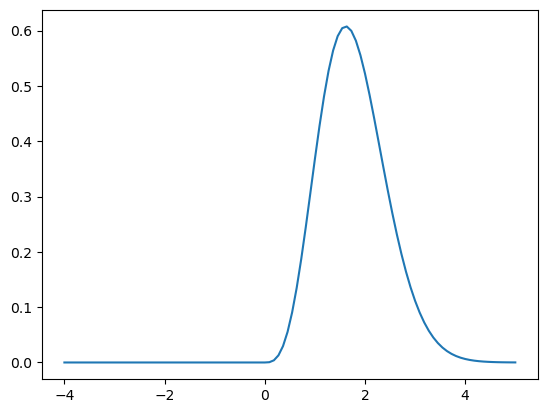

In [21]:
plt.plot(zvec, values)

<lambdifygenerated-8>:2: RuntimeWarning: divide by zero encountered in true_divide
  return -1/4*sqrt(2)*z**2*(-2*sqrt(pi)*(2 - erfc((1/2)*sqrt(2)*z)) - 2*sqrt(2)*exp(-1/2*z**2)/z)*exp(-1/2*z**2) - 1/2*sqrt(2)*((1/2)*sqrt(pi)*(-1/2*z**2 - 1/2)*(-2*sqrt(pi)*(2 - erfc((1/2)*sqrt(2)*z)) - 2*sqrt(2)*exp(-1/2*z**2)/z)*exp((1/2)*z**2) - 1/2*sqrt(2)*sqrt(pi)/z)*exp(-z**2)/sqrt(pi)
<lambdifygenerated-8>:2: RuntimeWarning: invalid value encountered in multiply
  return -1/4*sqrt(2)*z**2*(-2*sqrt(pi)*(2 - erfc((1/2)*sqrt(2)*z)) - 2*sqrt(2)*exp(-1/2*z**2)/z)*exp(-1/2*z**2) - 1/2*sqrt(2)*((1/2)*sqrt(pi)*(-1/2*z**2 - 1/2)*(-2*sqrt(pi)*(2 - erfc((1/2)*sqrt(2)*z)) - 2*sqrt(2)*exp(-1/2*z**2)/z)*exp((1/2)*z**2) - 1/2*sqrt(2)*sqrt(pi)/z)*exp(-z**2)/sqrt(pi)
<lambdifygenerated-8>:2: RuntimeWarning: invalid value encountered in subtract
  return -1/4*sqrt(2)*z**2*(-2*sqrt(pi)*(2 - erfc((1/2)*sqrt(2)*z)) - 2*sqrt(2)*exp(-1/2*z**2)/z)*exp(-1/2*z**2) - 1/2*sqrt(2)*((1/2)*sqrt(pi)*(-1/2*z**2 - 1/2)*(-2*sqrt(p

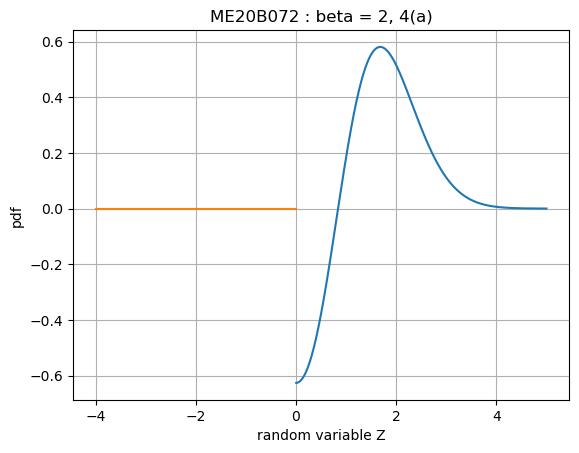

In [ ]:
def one(val) : 
    return 0
one2 = np.vectorize(one)

xvec = np.linspace(0,5,1000)
xvec2 = np.linspace(-4,0,1000)
plt.plot(xvec, pdf_num(xvec))
plt.plot(xvec2, one2(xvec2))
plt.title("ME20B072 : beta = 2, 4(a)")
plt.grid()
plt.xlabel("random variable Z")
plt.ylabel('pdf')
plt.show()